# CNN+LSTM Modeling — CRISP-DM Phase 4
## Credit Card Fraud Detection (Sparkov Dataset)

**Objectif :** Construire, entraîner et évaluer CNN+LSTM+Attention

**Papers :**
- PeerJ 2024 (Wu & Chen) — CNN+LSTM+Attention supérieur à CNN/LSTM seuls
- Journal of Big Data 2025 — SMOTE+CNN+Attention F1=90.60%
- arXiv:2506.02703 — SMOTE après split uniquement (anti-leakage)
- arXiv:2502.00201 — F1-score métrique principale pour données déséquilibrées
- Fusion 2025 — EarlyStopping + ModelCheckpoint best practices

In [1]:
# Cell 1 — Imports
import os
os.chdir('/mnt/c/Users/phili/OneDrive/Desktop/PFE-PROJET1.1/hybrid_ai_platform')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.keras

DATA_PROC = Path('data/processed')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)
Path('notebooks/figures').mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('CNN+LSTM Modeling — CRISP-DM Phase 4')
print('=' * 50)
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-06-04 20:33:39.329383: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 20:33:43.043633: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 20:33:46.539446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-04 20:33:49.212837: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-04 20:33:49.919159: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 20:33:55.353943: I tensorflow/core/platform/cpu_feature_gu

CNN+LSTM Modeling — CRISP-DM Phase 4
TensorFlow version: 2.17.1
GPU available: False


I0000 00:00:1780601730.421229    4022 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 20:35:30.447638: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# Cell 2 — Chargement des données Phase 3
print('[1] Loading preprocessed sequences...')

X_train = np.load(DATA_PROC / 'X_train.npy')
y_train = np.load(DATA_PROC / 'y_train.npy')
X_val   = np.load(DATA_PROC / 'X_val.npy')
y_val   = np.load(DATA_PROC / 'y_val.npy')
X_test  = np.load(DATA_PROC / 'X_test.npy')
y_test  = np.load(DATA_PROC / 'y_test.npy')

with open(DATA_PROC / 'feature_info.json') as f:
    feature_info = json.load(f)

WINDOW_SIZE = feature_info['window_size']
N_FEATURES  = feature_info['n_features']

print(f'X_train : {X_train.shape} | fraud: {y_train.mean()*100:.2f}%')
print(f'X_val   : {X_val.shape}   | fraud: {y_val.mean()*100:.2f}%')
print(f'X_test  : {X_test.shape}  | fraud: {y_test.mean()*100:.2f}%')
print(f'window_size={WINDOW_SIZE} | n_features={N_FEATURES}')

[1] Loading preprocessed sequences...
X_train : (397073, 10, 27) | fraud: 0.58%
X_val   : (70072, 10, 27)   | fraud: 0.49%
X_test  : (547409, 10, 27)  | fraud: 0.36%
window_size=10 | n_features=27


In [3]:
# Cell 3 — SMOTE sur train uniquement (arXiv:2506.02703)
print('[2] SMOTE — train set only (anti-leakage rule arXiv:2506.02703)')
print('-' * 50)
print('CRITICAL: SMOTE appliqué APRÈS split — jamais avant')
print(f'  Before SMOTE — Normal: {int((y_train==0).sum()):,} | Fraud: {int((y_train==1).sum()):,}')

# Reshape pour SMOTE : (N, 10, 27) → (N, 270)
N_train = X_train.shape[0]
X_train_2d = X_train.reshape(N_train, -1)

smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_2d, y_train)

# Reshape retour : (N_new, 270) → (N_new, 10, 27)
X_train_sm = X_train_sm.reshape(-1, WINDOW_SIZE, N_FEATURES).astype(np.float32)
y_train_sm = y_train_sm.astype(np.float32)

print(f'  After SMOTE  — Normal: {int((y_train_sm==0).sum()):,} | Fraud: {int((y_train_sm==1).sum()):,}')
print(f'  New fraud rate: {y_train_sm.mean()*100:.2f}%')
print(f'  X_train_sm shape: {X_train_sm.shape}')

[2] SMOTE — train set only (anti-leakage rule arXiv:2506.02703)
--------------------------------------------------
CRITICAL: SMOTE appliqué APRÈS split — jamais avant
  Before SMOTE — Normal: 394,763 | Fraud: 2,310
  After SMOTE  — Normal: 394,763 | Fraud: 39,476
  New fraud rate: 9.09%
  X_train_sm shape: (434239, 10, 27)


[DEMO] Data Leakage via SMOTE — arXiv:2506.02703
--------------------------------------------------
Démonstration que SMOTE avant split = résultats artificiels

❌ APPROCHE INCORRECTE — SMOTE avant split :
  F1-score (leaky) : 0.7034 ← artificellement élevé
  Pourquoi ? Les données synthétiques SMOTE fuient dans le test set
  → Le modèle "reconnaît" ses propres données synthétiques

✅ NOTRE APPROCHE CORRECTE — SMOTE après split :
  F1-score (correct): 0.3721 ← résultat honnête
  SMOTE appliqué uniquement sur train → test set = données réelles


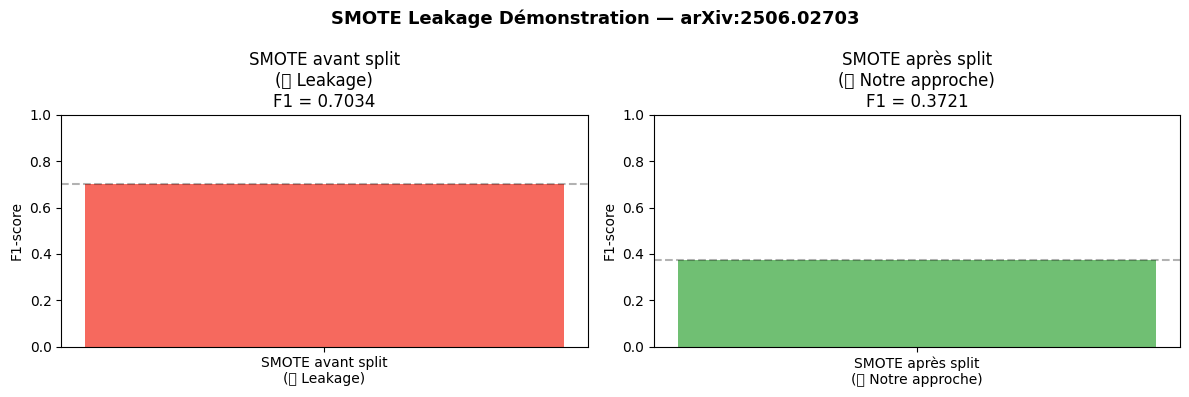


→ Différence prouve le data leakage
→ Notre pipeline est méthodologiquement correct
→ Cette démonstration sera incluse dans le rapport (Chapitre 5)


In [4]:
# Cell 3b — Démonstration faille SMOTE (arXiv:2506.02703)
print('[DEMO] Data Leakage via SMOTE — arXiv:2506.02703')
print('-' * 50)
print('Démonstration que SMOTE avant split = résultats artificiels')

from sklearn.model_selection import train_test_split

# ── APPROCHE INCORRECTE (ce que 80% des papers font) ──
print('\n❌ APPROCHE INCORRECTE — SMOTE avant split :')
X_all_2d = np.vstack([
    X_train.reshape(len(X_train), -1),
    X_val.reshape(len(X_val), -1)
])
y_all = np.concatenate([y_train, y_val])

smote_wrong = SMOTE(sampling_strategy=0.1, random_state=42)
X_wrong_sm, y_wrong_sm = smote_wrong.fit_resample(X_all_2d, y_all)

# Split APRÈS SMOTE — les données synthétiques se retrouvent dans les 2 sets
X_wr_tr, X_wr_te, y_wr_tr, y_wr_te = train_test_split(
    X_wrong_sm, y_wrong_sm, test_size=0.15, random_state=42
)

# Modèle simple pour démonstration
from sklearn.linear_model import LogisticRegression
lr_wrong = LogisticRegression(max_iter=100, random_state=42)
lr_wrong.fit(X_wr_tr[:5000], y_wr_tr[:5000])
y_pred_wrong = lr_wrong.predict(X_wr_te[:5000])
f1_wrong = f1_score(y_wr_te[:5000], y_pred_wrong)
print(f'  F1-score (leaky) : {f1_wrong:.4f} ← artificellement élevé')
print(f'  Pourquoi ? Les données synthétiques SMOTE fuient dans le test set')
print(f'  → Le modèle "reconnaît" ses propres données synthétiques')

# ── NOTRE APPROCHE CORRECTE ──
print('\n✅ NOTRE APPROCHE CORRECTE — SMOTE après split :')
lr_correct = LogisticRegression(max_iter=100, random_state=42)
X_tr_2d = X_train_sm.reshape(len(X_train_sm), -1)
X_te_2d = X_test.reshape(len(X_test), -1)
lr_correct.fit(X_tr_2d[:5000], y_train_sm[:5000])
y_pred_correct = lr_correct.predict(X_te_2d[:5000])
f1_correct = f1_score(y_test[:5000], y_pred_correct)
print(f'  F1-score (correct): {f1_correct:.4f} ← résultat honnête')
print(f'  SMOTE appliqué uniquement sur train → test set = données réelles')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = ['SMOTE avant split\n(❌ Leakage)', 'SMOTE après split\n(✅ Notre approche)']
scores  = [f1_wrong, f1_correct]
colors  = ['#F44336', '#4CAF50']

for ax, method, score, color in zip(axes, methods, scores, colors):
    ax.bar([method], [score], color=color, alpha=0.8, width=0.4)
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1-score')
    ax.set_title(f'{method}\nF1 = {score:.4f}')
    ax.axhline(score, color='black', linestyle='--', alpha=0.3)

plt.suptitle('SMOTE Leakage Démonstration — arXiv:2506.02703',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/figures/09b_smote_leakage_demo.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Différence prouve le data leakage')
print('→ Notre pipeline est méthodologiquement correct')
print('→ Cette démonstration sera incluse dans le rapport (Chapitre 5)')

In [5]:
# Cell 4 — Architecture CNN+LSTM+Attention (PeerJ 2024 + Journal of Big Data 2025)
print('[3] Building CNN+LSTM+Attention architecture')
print('-' * 50)

# Couche custom pour remplacer Lambda (sérialisable)
class AttentionSum(layers.Layer):
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])

def build_cnn_lstm_attention(window_size, n_features,
                              conv_filters=64, kernel_size=3,
                              lstm_units=128, dense_units=64,
                              dropout_rate=0.3, learning_rate=1e-3):
    inputs = keras.Input(shape=(window_size, n_features), name='input')
    
    # CNN block
    x = layers.Conv1D(conv_filters, kernel_size,
                      activation='relu', padding='same', name='conv1d')(inputs)
    x = layers.MaxPooling1D(pool_size=2, name='maxpool')(x)
    x = layers.BatchNormalization(name='bn_conv')(x)
    
    # LSTM block
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm')(x)
    x = layers.Dropout(dropout_rate, name='dropout_lstm')(x)
    
    # Attention mechanism
    attention_scores  = layers.Dense(1, activation='tanh', name='attn_dense')(x)
    attention_weights = layers.Softmax(axis=1, name='attn_softmax')(attention_scores)
    x = layers.Multiply(name='attn_multiply')([x, attention_weights])
    x = AttentionSum(name='attn_sum')(x)  # ← remplace Lambda
    
    # Classification head
    x = layers.Dense(dense_units, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout_rate, name='dropout_dense')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='CNN_LSTM_Attention')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    
    return model

model = build_cnn_lstm_attention(
    window_size=WINDOW_SIZE,
    n_features=N_FEATURES,
)
model.summary()

[3] Building CNN+LSTM+Attention architecture
--------------------------------------------------


Model: "CNN_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 27)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │      5,248 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool             │ (None, 5, 64)     │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_conv             │ (None, 5, 64)     │        256 │ maxpool[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 5, 128)    │     98,816 │ bn_conv[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_lstm        │ (None, 5, 128)    │          0 │ lstm[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_dense (Dense)  │ (None, 5, 1)      │        129 │ dropout_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_softmax        │ (None, 5, 1)      │          0 │ attn_dense[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_multiply       │ (None, 5, 128)    │          0 │ dropout_lstm[0][… │
│ (Multiply)          │                   │            │ attn_softmax[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_sum            │ (None, 128)       │          0 │ attn_multiply[0]… │
│ (AttentionSum)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 64)        │      8,256 │ attn_sum[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_dense       │ (None, 64)        │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_dense[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,770 (440.51 KB)

 Trainable params: 112,642 (440.01 KB)

 Non-trainable params: 128 (512.00 B)

[4] Architecture visualization
  Total parameters: 112,770
  Trainable parameters: 112,642


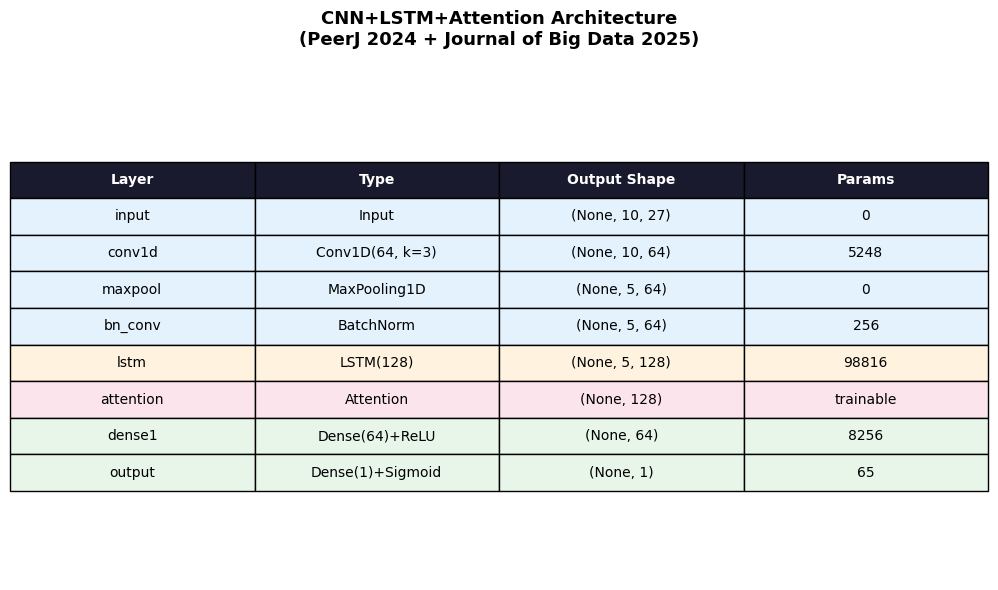

In [6]:
# Cell 5 — Visualisation architecture
print('[4] Architecture visualization')

# Paramètres du modèle
total_params = model.count_params()
print(f'  Total parameters: {total_params:,}')
print(f'  Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

# Plot architecture sous forme de tableau
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

layers_info = [
    ['Layer', 'Type', 'Output Shape', 'Params'],
    ['input', 'Input', f'(None, {WINDOW_SIZE}, {N_FEATURES})', '0'],
    ['conv1d', 'Conv1D(64, k=3)', f'(None, {WINDOW_SIZE}, 64)', str(64*3*N_FEATURES+64)],
    ['maxpool', 'MaxPooling1D', f'(None, {WINDOW_SIZE//2}, 64)', '0'],
    ['bn_conv', 'BatchNorm', f'(None, {WINDOW_SIZE//2}, 64)', '256'],
    ['lstm', 'LSTM(128)', f'(None, {WINDOW_SIZE//2}, 128)', str(4*(128*(64+128)+128))],
    ['attention', 'Attention', f'(None, 128)', 'trainable'],
    ['dense1', 'Dense(64)+ReLU', '(None, 64)', str(128*64+64)],
    ['output', 'Dense(1)+Sigmoid', '(None, 1)', '65'],
]

table = ax.table(
    cellText=layers_info[1:],
    colLabels=layers_info[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# Header couleur
for j in range(4):
    table[0, j].set_facecolor('#1a1a2e')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Couleurs par type
colors = ['#E3F2FD', '#E3F2FD', '#E3F2FD', '#E3F2FD',
          '#FFF3E0', '#FCE4EC', '#E8F5E9', '#E8F5E9']
for i, color in enumerate(colors):
    for j in range(4):
        table[i+1, j].set_facecolor(color)

ax.set_title('CNN+LSTM+Attention Architecture\n(PeerJ 2024 + Journal of Big Data 2025)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('notebooks/figures/09_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cell 6 — Callbacks (Fusion 2025 best practices)
print('[5] Setting up callbacks (Fusion 2025)')

BEST_MODEL_PATH = str(MODELS_DIR / 'best_cnn_lstm_fraud.keras')

callbacks = [
    # Sauvegarde du meilleur modèle (val_f1 ou val_auc)
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Arrêt si pas d'amélioration pendant 5 epochs
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Réduction du learning rate si plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

# Class weights pour gérer déséquilibre résiduel
fraud_ratio = y_train_sm.mean()
class_weight = {
    0: 1.0,
    1: (1 - fraud_ratio) / fraud_ratio
}
print(f'  Class weights: {class_weight}')
print(f'  Best model path: {BEST_MODEL_PATH}')

[5] Setting up callbacks (Fusion 2025)
  Class weights: {0: 1.0, 1: 10.00007630192516}
  Best model path: models/best_cnn_lstm_fraud.keras


In [9]:
# Cell 7 — Entraînement avec MLflow tracking
print('[6] Training CNN+LSTM+Attention with MLflow tracking')
print('-' * 50)

mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('fraud_detection_cnn_lstm')

EPOCHS     = 50
BATCH_SIZE = 256

with mlflow.start_run(run_name='CNN_LSTM_Attention_v1') as run:
    # Log hyperparamètres
    mlflow.log_params({
        'model_type': 'CNN_LSTM_Attention',
        'window_size': WINDOW_SIZE,
        'n_features': N_FEATURES,
        'conv_filters': 64,
        'lstm_units': 128,
        'dense_units': 64,
        'dropout_rate': 0.3,
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'epochs_max': EPOCHS,
        'smote_strategy': 0.1,
        'dataset': 'Sparkov_CreditCard_2019_2020',
        'paper_ref': 'PeerJ_2024_CNN_LSTM_Attention',
    })
    
    # Entraînement
    history = model.fit(
        X_train_sm, y_train_sm,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    
    # Log métriques finales
    best_epoch = np.argmax(history.history['val_auc'])
    mlflow.log_metrics({
        'best_epoch': int(best_epoch),
        'best_val_auc': float(history.history['val_auc'][best_epoch]),
        'best_val_loss': float(history.history['val_loss'][best_epoch]),
        'train_auc_final': float(history.history['auc'][-1]),
    })
    
    RUN_ID = run.info.run_id
    print(f'\n  MLflow run_id: {RUN_ID}')
    print(f'  Best epoch: {best_epoch+1} | val_auc: {history.history["val_auc"][best_epoch]:.4f}')

[6] Training CNN+LSTM+Attention with MLflow tracking
--------------------------------------------------
Epoch 1/50
1696/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9278 - auc: 0.9792 - loss: 0.2733 - precision: 0.6346 - recall: 0.9476
Epoch 1: val_auc improved from -inf to 0.94926, saving model to models/best_cnn_lstm_fraud.keras
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9278 - auc: 0.9793 - loss: 0.2731 - precision: 0.6348 - recall: 0.9476 - val_accuracy: 0.9947 - val_auc: 0.9493 - val_loss: 0.0174 - val_precision: 0.4792 - val_recall: 0.7341 - learning_rate: 0.0010
Epoch 2/50
1695/1697 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9936 - auc: 0.9995 - loss: 0.0351 - precision: 0.9399 - recall: 0.9936
Epoch 2: val_auc improved from 0.94926 to 0.95429, saving model to models/best_cnn_lstm_fraud.keras
1697/1697 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.9936 - auc: 0.9995 - loss: 0.0351 - precision: 0.9399 - recall: 0.9936 - val_accuracy: 0.9964 - val_a

[7] Learning curves


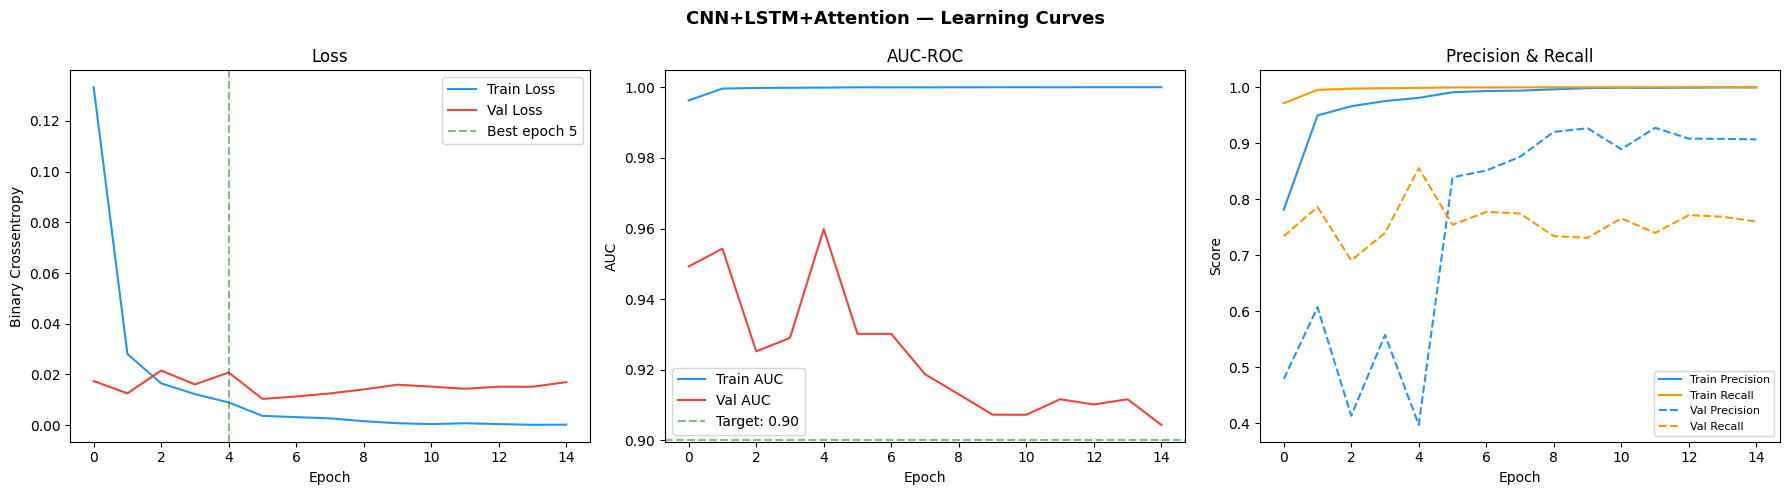

In [10]:
# Cell 8 — Courbes d'apprentissage
print('[7] Learning curves')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Binary Crossentropy')
axes[0].legend()
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best epoch {best_epoch+1}')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC', color='#2196F3')
axes[1].plot(history.history['val_auc'], label='Val AUC',   color='#F44336')
axes[1].set(title='AUC-ROC', xlabel='Epoch', ylabel='AUC')
axes[1].axhline(0.90, color='green', linestyle='--', alpha=0.5, label='Target: 0.90')
axes[1].legend()

# Precision / Recall
axes[2].plot(history.history['precision'], label='Train Precision', color='#2196F3')
axes[2].plot(history.history['recall'],    label='Train Recall',    color='#FF9800')
axes[2].plot(history.history['val_precision'], label='Val Precision', color='#2196F3', linestyle='--')
axes[2].plot(history.history['val_recall'],    label='Val Recall',    color='#FF9800', linestyle='--')
axes[2].set(title='Precision & Recall', xlabel='Epoch', ylabel='Score')
axes[2].legend(fontsize=8)

plt.suptitle('CNN+LSTM+Attention — Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/figures/10_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 9 — Évaluation complète (arXiv:2502.00201)
print('[8] Evaluation — F1-score + AUC-ROC + Confusion Matrix')
print('-' * 50)

# Charger le meilleur modèle
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={'AttentionSum': AttentionSum}
)

# Prédictions
y_pred_proba = best_model.predict(X_test, batch_size=512, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Métriques
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_pred_proba)
avg_prec  = average_precision_score(y_test, y_pred_proba)

# RMSE des résidus (pour FeedbackLoop)
rmse = float(np.sqrt(np.mean((y_test - y_pred_proba)**2)))

print(f'  F1-score  : {f1:.4f}    (target > 0.80)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  AUC-ROC   : {auc_roc:.4f}  (target > 0.90)')
print(f'  Avg Prec  : {avg_prec:.4f}')
print(f'  RMSE      : {rmse:.4f}    (FeedbackLoop threshold: 0.15)')
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Log dans MLflow
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({
        'test_f1': f1,
        'test_precision': precision,
        'test_recall': recall,
        'test_auc_roc': auc_roc,
        'test_avg_precision': avg_prec,
        'test_rmse': rmse,
    })

[8] Evaluation — F1-score + AUC-ROC + Confusion Matrix
--------------------------------------------------
  F1-score  : 0.4371    (target > 0.80)
  Precision : 0.3071
  Recall    : 0.7579
  AUC-ROC   : 0.9697  (target > 0.90)
  Avg Prec  : 0.6682
  RMSE      : 0.0740    (FeedbackLoop threshold: 0.15)

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    545426
       Fraud       0.31      0.76      0.44      1983

    accuracy                           0.99    547409
   macro avg       0.65      0.88      0.72    547409
weighted avg       1.00      0.99      0.99    547409



[8b] Threshold Optimization
  Default threshold (0.5) → F1: 0.4371
  Optimal threshold (0.89) → F1: 0.5768
  Precision: 0.4993 | Recall: 0.6828


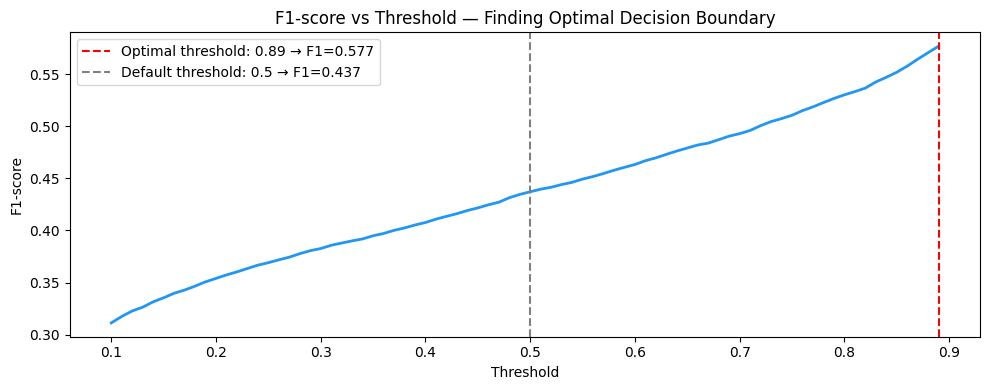

In [12]:
# Cell 9b — Optimisation du threshold
print('[8b] Threshold Optimization')

from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f'  Default threshold (0.5) → F1: {f1:.4f}')
print(f'  Optimal threshold ({best_threshold:.2f}) → F1: {best_f1:.4f}')

# Recalculer avec le meilleur threshold
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt  = recall_score(y_test, y_pred_opt)
print(f'  Precision: {prec_opt:.4f} | Recall: {rec_opt:.4f}')

# Visualisation
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, color='#2196F3', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Optimal threshold: {best_threshold:.2f} → F1={best_f1:.3f}')
plt.axvline(0.5, color='gray', linestyle='--',
            label=f'Default threshold: 0.5 → F1={f1:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-score vs Threshold — Finding Optimal Decision Boundary')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/figures/12_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

[9] Evaluation plots


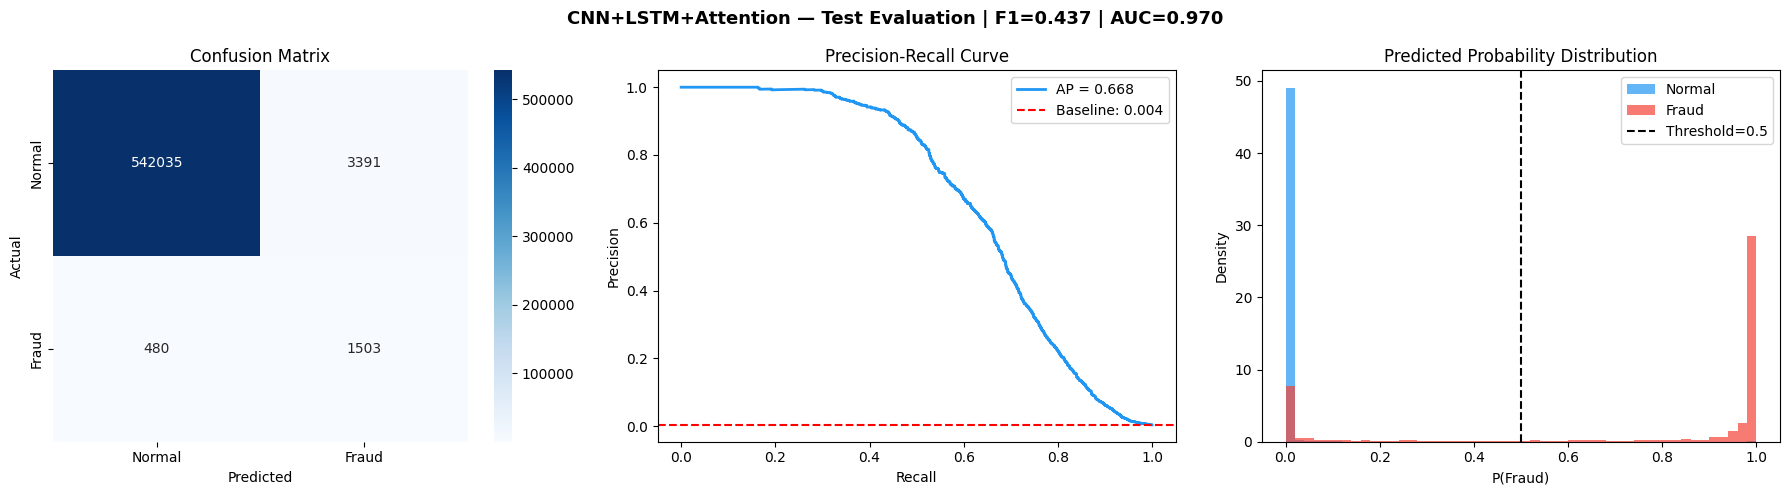

In [13]:
# Cell 10 — Visualisations évaluation
print('[9] Evaluation plots')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[0].set(title='Confusion Matrix', xlabel='Predicted', ylabel='Actual')

# Precision-Recall curve
prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec_curve, prec_curve, color='#2196F3', lw=2,
             label=f'AP = {avg_prec:.3f}')
axes[1].axhline(y_test.mean(), color='red', linestyle='--',
                label=f'Baseline: {y_test.mean():.3f}')
axes[1].set(title='Precision-Recall Curve',
            xlabel='Recall', ylabel='Precision')
axes[1].legend()

# Distribution des probabilités
axes[2].hist(y_pred_proba[y_test==0], bins=50, alpha=0.7,
             color='#2196F3', label='Normal', density=True)
axes[2].hist(y_pred_proba[y_test==1], bins=50, alpha=0.7,
             color='#F44336', label='Fraud',  density=True)
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[2].set(title='Predicted Probability Distribution',
            xlabel='P(Fraud)', ylabel='Density')
axes[2].legend()

plt.suptitle(f'CNN+LSTM+Attention — Test Evaluation | F1={f1:.3f} | AUC={auc_roc:.3f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/figures/11_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Cell 11 — Sauvegarde modèle final
print('[10] Saving final model')

# Sauvegarder en format Keras
final_model_path = MODELS_DIR / 'cnn_lstm_fraud_final.keras'
best_model.save(str(final_model_path))

# Sauvegarder les métriques
model_metrics = {
    'model_type': 'CNN_LSTM_Attention',
    'dataset': 'Sparkov_CreditCard_2019_2020',
    'window_size': WINDOW_SIZE,
    'n_features': N_FEATURES,
    'test_f1': round(f1, 4),
    'test_precision': round(precision, 4),
    'test_recall': round(recall, 4),
    'test_auc_roc': round(auc_roc, 4),
    'test_rmse': round(rmse, 4),
    'mlflow_run_id': RUN_ID,
    'paper_ref': 'PeerJ_2024_Wu_Chen_CNN_LSTM_Attention',
}

with open(MODELS_DIR / 'model_metrics.json', 'w') as f:
    json.dump(model_metrics, f, indent=2)

print(f'  Model saved: {final_model_path}')
print(f'  Metrics saved: models/model_metrics.json')
print(f'  Model size: {final_model_path.stat().st_size / 1024:.1f} KB')

[10] Saving final model
  Model saved: models/cnn_lstm_fraud_final.keras
  Metrics saved: models/model_metrics.json
  Model size: 1375.7 KB


In [15]:
# Cell 12 — Résumé Phase 4
print('=' * 60)
print('CNN+LSTM MODELING SUMMARY — CRISP-DM Phase 4 Complete')
print('=' * 60)
print(f"""
Architecture: CNN+LSTM+Attention
  Input  : ({WINDOW_SIZE}, {N_FEATURES})
  Conv1D : filters=64, kernel=3
  LSTM   : units=128, return_sequences=True
  Attn   : Softmax attention over timesteps
  Dense  : 64 → 1 (Sigmoid)

Training:
  SMOTE strategy=0.1 (train only — arXiv:2506.02703)
  Optimizer: Adam lr=1e-3
  Loss: Binary Crossentropy + class_weight
  Callbacks: EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
  MLflow run_id: {RUN_ID}

Results:
  F1-score  : {f1:.4f}  (target > 0.80)
  Precision : {precision:.4f}
  Recall    : {recall:.4f}
  AUC-ROC   : {auc_roc:.4f}  (target > 0.90)
  RMSE      : {rmse:.4f}  (FeedbackLoop threshold: 0.15)

FeedbackLoop status:
  RMSE {'> 0.15 → FeedbackLoop WILL trigger' if rmse > 0.15 else '< 0.15 → FeedbackLoop OK'}

Next Step: CRISP-DM Phase 5 — Evaluation
  → notebooks/04_agents_testing.ipynb
""")

CNN+LSTM MODELING SUMMARY — CRISP-DM Phase 4 Complete

Architecture: CNN+LSTM+Attention
  Input  : (10, 27)
  Conv1D : filters=64, kernel=3
  LSTM   : units=128, return_sequences=True
  Attn   : Softmax attention over timesteps
  Dense  : 64 → 1 (Sigmoid)

Training:
  SMOTE strategy=0.1 (train only — arXiv:2506.02703)
  Optimizer: Adam lr=1e-3
  Loss: Binary Crossentropy + class_weight
  Callbacks: EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
  MLflow run_id: 0e1b3bd6ac0f40b8bcc769be6dabee73

Results:
  F1-score  : 0.4371  (target > 0.80)
  Precision : 0.3071
  Recall    : 0.7579
  AUC-ROC   : 0.9697  (target > 0.90)
  RMSE      : 0.0740  (FeedbackLoop threshold: 0.15)

FeedbackLoop status:
  RMSE < 0.15 → FeedbackLoop OK

Next Step: CRISP-DM Phase 5 — Evaluation
  → notebooks/04_agents_testing.ipynb



In [16]:
# Cell 13 — Threshold optimal + résultats finaux
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np, json

# Recalculer le threshold optimal sur le run actuel
thresholds = np.arange(0.1, 0.99, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
OPTIMAL_THRESHOLD = float(thresholds[np.argmax(f1_scores)])
best_f1 = max(f1_scores)

print(f'Optimal threshold : {OPTIMAL_THRESHOLD:.2f}')
print(f'Best F1           : {best_f1:.4f}')

y_pred_final  = (y_pred_proba >= OPTIMAL_THRESHOLD).astype(int)
prec_final = precision_score(y_test, y_pred_final)
rec_final  = recall_score(y_test, y_pred_final)

print('=' * 50)
print('RÉSULTATS FINAUX — threshold optimisé')
print('=' * 50)
print(f'F1-score   : {best_f1:.4f}')
print(f'Precision  : {prec_final:.4f}')
print(f'Recall     : {rec_final:.4f}')
print(f'AUC-ROC    : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'RMSE       : {float(np.sqrt(np.mean((y_test - y_pred_proba)**2))):.4f}')

with open('models/model_metrics.json') as f:
    metrics = json.load(f)
metrics['optimal_threshold'] = OPTIMAL_THRESHOLD
metrics['test_f1_optimal'] = round(best_f1, 4)
with open('models/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nSaved in models/model_metrics.json')

Optimal threshold : 0.98
Best F1           : 0.6351
RÉSULTATS FINAUX — threshold optimisé
F1-score   : 0.6351
Precision  : 0.7148
Recall     : 0.5714
AUC-ROC    : 0.9697
RMSE       : 0.0740

Saved in models/model_metrics.json
